# Graphing Video Game Sales

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
sns.set_theme(
    style='whitegrid',        
    palette='colorblind',     
    font='sans-serif',       
    rc={
        "axes.spines.top": False,    
        "axes.spines.right": False,  
        "axes.labelweight": "bold", 
        "axes.titleweight": "bold",  
        "axes.titlesize": 14,
        "figure.autolayout": True   
    }
)




In [27]:
games = pd.read_csv('top100videogamesales.csv')
games.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Nintendo,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Mario Kart Wii,Nintendo,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
2,3,Wii Sports Resort,Nintendo,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
3,4,New Super Mario Bros.,Nintendo,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
4,5,Wii Play,Nintendo,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
5,6,New Super Mario Bros. Wii,Nintendo,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
6,7,Nintendogs,Nintendo,2005,Simulation,Nintendo,9.07,11.00,1.93,2.75,24.76
7,8,Mario Kart DS,Nintendo,2005,Racing,Nintendo,9.81,7.57,4.13,1.92,23.42
8,9,Wii Fit,Nintendo,2007,Sports,Nintendo,8.94,8.03,3.60,2.15,22.72
9,10,Wii Fit Plus,Nintendo,2009,Sports,Nintendo,9.09,8.59,2.53,1.79,22.00


In [28]:
games.info()
# games.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          100 non-null    int64  
 1   Name          100 non-null    object 
 2   Platform      100 non-null    object 
 3   Year          100 non-null    int64  
 4   Genre         100 non-null    object 
 5   Publisher     100 non-null    object 
 6   NA_Sales      100 non-null    float64
 7   EU_Sales      100 non-null    float64
 8   JP_Sales      100 non-null    float64
 9   Other_Sales   100 non-null    float64
 10  Global_Sales  100 non-null    float64
dtypes: float64(5), int64(2), object(4)
memory usage: 8.7+ KB


# Regional Sales by Publisher
As illustrated in the chart, Nintendo leads all publishers in total sales. It has a  significantly taller bar which  reflects their market dominance, with each bar's height representing a publisher's cumulative sales.

<Axes: xlabel='Publisher'>

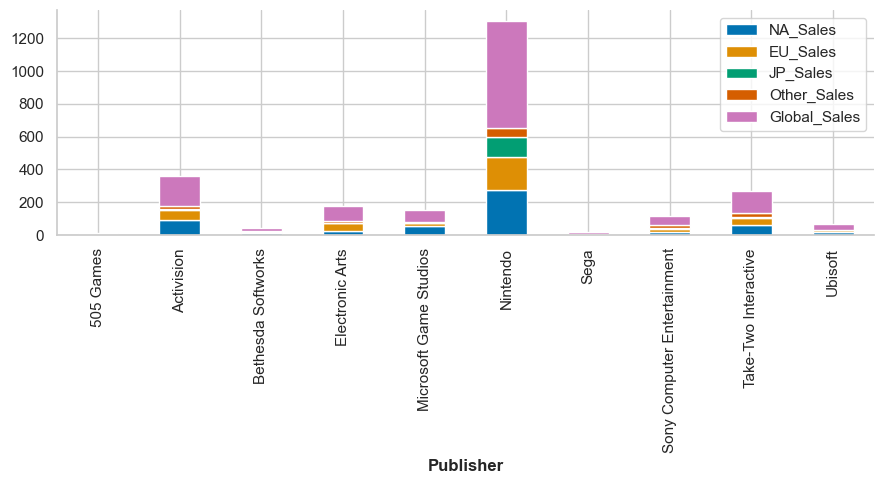

In [29]:
regional_sales = games.groupby('Publisher')[['NA_Sales', 'EU_Sales', 'JP_Sales','Other_Sales', 'Global_Sales']].sum()
regional_sales.plot(kind='bar', stacked='True', figsize=(9,5))


# Global Sales by Year
Below chart explains how Global video game sales grew steadily and peaked around year 2006, after which 
they declined and stablized at lower levels, with some minor fluctuations in later years

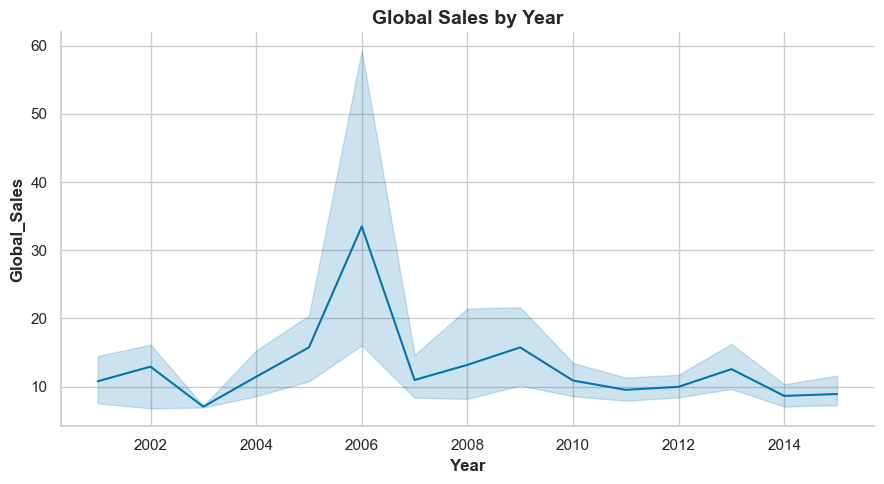

In [30]:
plt.figure(figsize=(9,5))
sns.lineplot(data=games, x='Year', y= 'Global_Sales')
plt.title('Global Sales by Year')
plt.show()

# Global Sales Distribution for Action Games
The below chart shows a Global Sales distribution of Action games. 
Per observations, we could tell the highest concentration of games is around **7-12**
and the distribution is positively skewed.

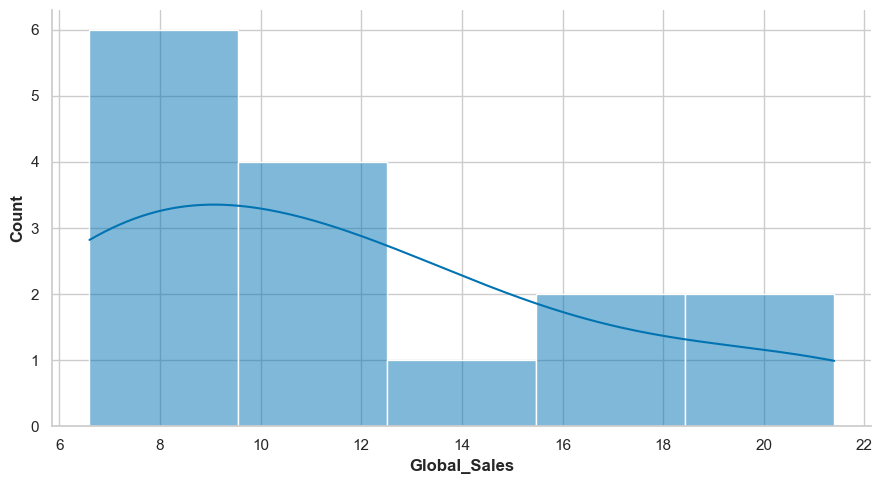

In [31]:
action_games = games[games['Genre']=='Action']

plt.figure(figsize=(9,5))
sns.histplot(data=action_games, x='Global_Sales',kde=True)
plt.show()


# North American Sales by Genre
The pie chart shows North American Sales by Genre, **Shooter** being the most preferred genre with **24.8%** and other genre which
comprises of Fighting, Puzzle and Simulation being the least with **5.7%**.

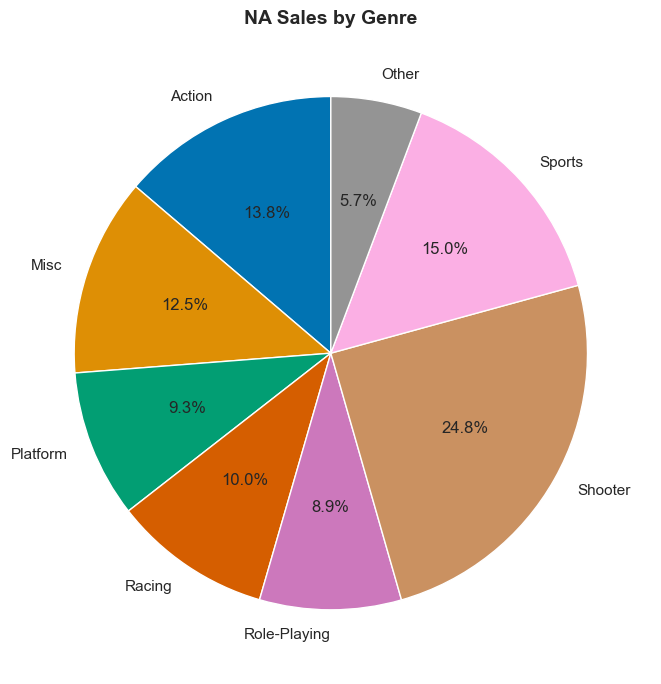

In [41]:
NA_sales = games.groupby('Genre')['NA_Sales'].sum()
threshold = NA_sales.sum() * 0.05
main = NA_sales[NA_sales >=threshold].copy()
other = NA_sales[NA_sales < threshold]
main['Other']= other.sum()


plt.figure(figsize=(10,7))
plt.pie(main, labels=main.index, autopct='%1.1f%%', startangle=90)
plt.title('NA Sales by Genre')
plt.show()

# European Sales by Genre
The pie chart below shows European sales by genre, with Sports being the most preferred and Platform the least. The 'Other' category comprises Fighting, Puzzle, and Simulation.

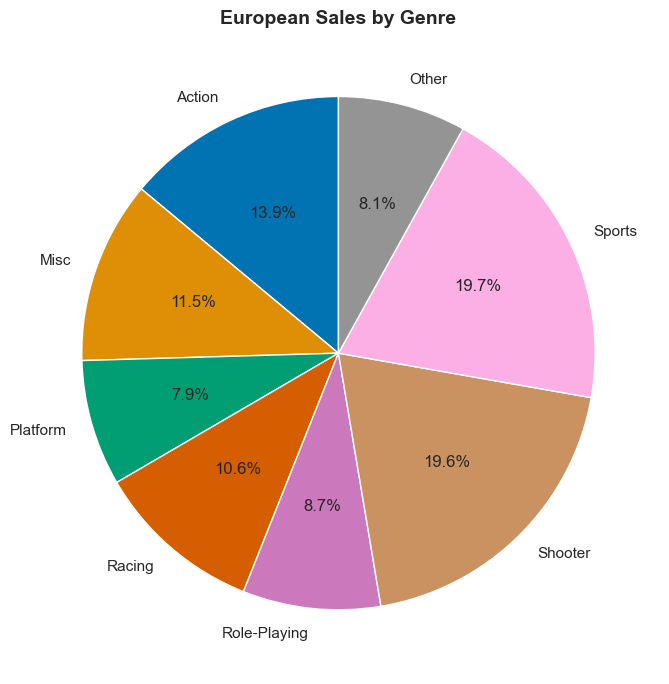

In [39]:
EA_Sales = games.groupby('Genre')['EU_Sales'].sum()
threshold = EA_Sales.sum() * 0.06
main = EA_Sales[EA_Sales >=threshold].copy()
other = EA_Sales[EA_Sales < threshold]
main['Other'] = other.sum()


plt.figure(figsize=(10,7))
plt.pie(main, labels=main.index, autopct='%1.1f%%', startangle=90)
plt.title('European Sales by Genre')
plt.show()

# Differences and similarities between the North American and European charts
In both charts, Shooter and Sports are the most preferred genres. Conversely, the least preferred genres are Other (Fighting, Puzzle, and Simulation) in North America and Platform in Europe.

# Count of Games by Platform
Looking at the chart below, Nitendo being the most used platform with 40+ counts, followed by Playstation and xbox respectively.

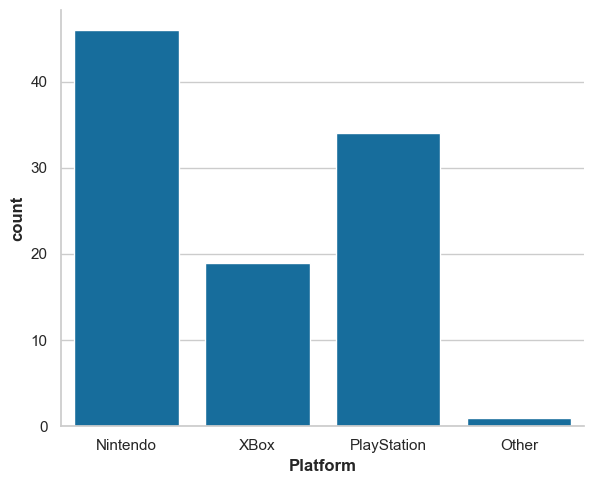

In [34]:

sns.catplot(kind='count', data=games , x='Platform', height=5 , aspect=1.2)


# What genre of game is present the most in the top 100 games from 2000-2015?
According to the chart, shooter is the most frequent genre among the top 100 games from 2000–2015, appearing more than 20 times.

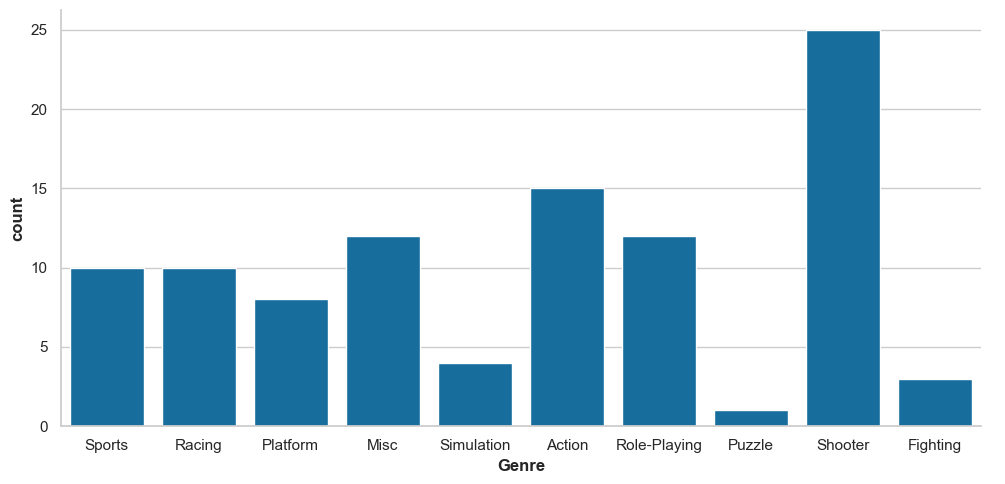

In [35]:
sns.catplot(kind='count', data=games, x= 'Genre', aspect=2)

# What percentage of global sales does PlayStation have in the dataset?
The percentage of playstation in Global Sales is **27.1%** making it the second highest in the Global sales

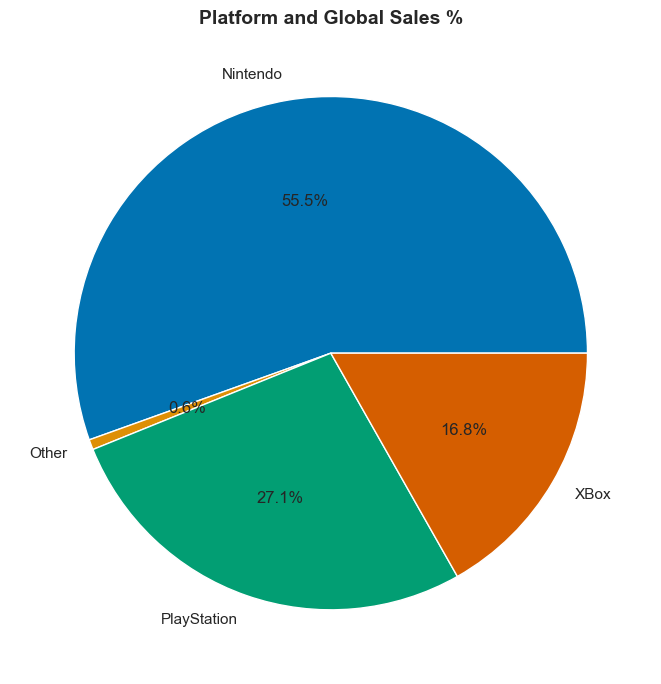

In [36]:
playstation = games.groupby('Platform').agg({'Global_Sales': 'sum'})
total_sales = playstation['Global_Sales'].sum()
playstation['Percentage'] = round((playstation['Global_Sales']/total_sales) * 100)
# playstation.head()
plt.figure(figsize=(10, 7))
plt.pie(playstation['Global_Sales'], 
        labels=playstation.index, 
        autopct='%1.1f%%', 
        ) 

plt.title('Platform and Global Sales %')
plt.show()

# What is the distribution of sales for Shooter games?
Per observation, the tallest bar appears in lower range(6-8), indicating that  more games fall
into the lower sales category and the distribution is bimodal.

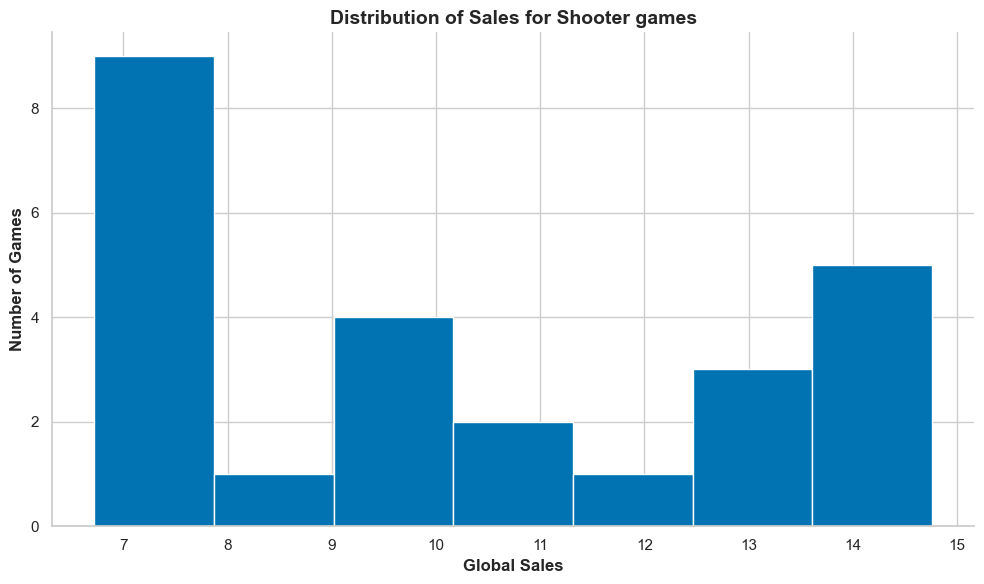

In [37]:
shooter_games = games[games['Genre']=='Shooter']
plt.figure(figsize=(10,6))
plt.hist(shooter_games['Global_Sales'], bins=7)
plt.title('Distribution of Sales for Shooter games')
plt.xlabel('Global Sales')
plt.ylabel('Number of Games')
plt.show()